In [3]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures


# Data Extraction

In [4]:
df=pd.read_csv('Ice_cream selling data.csv')

# info about data

In [5]:
df.head()

,Temperature (°C),Ice Cream Sales (units)
0,-4.662263,41.842986
1,-4.316559,34.661120
2,-4.213985,39.383001
3,-3.949661,37.539845
4,-3.578554,32.284531


In [6]:
df.corr()

,Temperature (°C),Ice Cream Sales (units)
Temperature (°C),1.000000,-0.175184
Ice Cream Sales (units),-0.175184,1.000000


<Axes: xlabel='Temperature (°C)', ylabel='Ice Cream Sales (units)'>

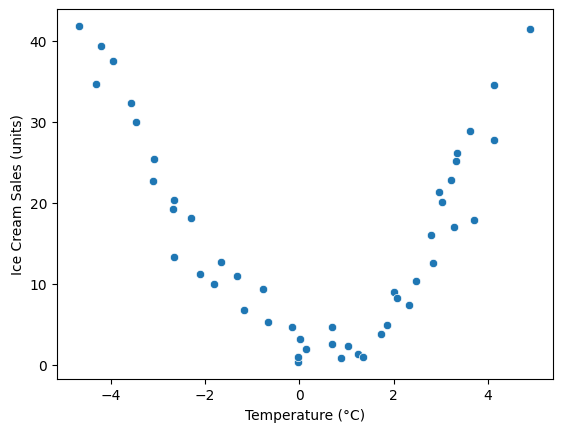

In [7]:
sns.scatterplot(x='Temperature (°C)',y='Ice Cream Sales (units)',data=df)

In [8]:
x=df[['Temperature (°C)']]
y=df['Ice Cream Sales (units)']

In [9]:
from sklearn.model_selection import train_test_split

In [10]:
xtrain,xtest,ytrain,ytest=train_test_split(x,y,test_size=0.2,random_state=42)

In [11]:
model=LinearRegression()

In [12]:
model.fit(xtrain,ytrain)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


here we use predict instead of fit_transform 

In [13]:
model.score(xtest,ytest)

-0.5751270190188227

In [14]:
model.score(xtrain,ytrain)

0.06579063815950037

In [15]:
poly=PolynomialFeatures(degree=2)

In [16]:
poly 

,degree,2
,interaction_only,False
,include_bias,True
,order,'C'


internally it uses ols method by incresing the degree of polynomial it will change the values
while passing less features in column of prediction it will give the error

In [17]:
poly.fit_transform(xtrain,ytrain)


array([[ 1.00000000e+00, -2.11186969e+00,  4.45999359e+00],
       [ 1.00000000e+00, -3.57855372e+00,  1.28060467e+01],
       [ 1.00000000e+00,  2.31859124e+00,  5.37586534e+00],
       [ 1.00000000e+00, -2.67246083e+00,  7.14204687e+00],
       [ 1.00000000e+00, -3.94966109e+00,  1.55998227e+01],
       [ 1.00000000e+00, -3.10844012e+00,  9.66239999e+00],
       [ 1.00000000e+00,  3.21136614e+00,  1.03128725e+01],
       [ 1.00000000e+00,  3.27004407e+00,  1.06931882e+01],
       [ 1.00000000e+00,  4.13086796e+00,  1.70640701e+01],
       [ 1.00000000e+00, -1.32637898e+00,  1.75928121e+00],
       [ 1.00000000e+00, -2.65228679e+00,  7.03462523e+00],
       [ 1.00000000e+00, -1.17312327e+00,  1.37621820e+00],
       [ 1.00000000e+00,  6.88780908e-01,  4.74419139e-01],
       [ 1.00000000e+00,  2.07510060e+00,  4.30604249e+00],
       [ 1.00000000e+00,  1.74000001e+00,  3.02760004e+00],
       [ 1.00000000e+00, -4.66226268e+00,  2.17366933e+01],
       [ 1.00000000e+00,  3.33593241e+00

In [18]:
xtrain_poly=poly.transform(xtrain)
xtest_poly=poly.transform(xtest)

In [19]:
model=LinearRegression()

In [20]:
model.fit(xtrain_poly,ytrain)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [21]:
model.score(xtrain_poly,ytrain)

0.9413665676490518

In [22]:
'''plt.scatter(xtrain['Temperature (°C)'],ytrain)
plt.scatter(xtrain['Temperature (°C)'],model.predict(xtrain))
ValueError: X has 1 features, but LinearRegression is expecting 3 features as input.'''


"plt.scatter(xtrain['Temperature (°C)'],ytrain)\nplt.scatter(xtrain['Temperature (°C)'],model.predict(xtrain))\nValueError: X has 1 features, but LinearRegression is expecting 3 features as input."

while we pass the columns name in the model creation the same column name should be passed in the prediction also otherwise it will give error

In [23]:
df['new']=df['Temperature (°C)']

In [24]:
model=LinearRegression()

In [25]:
model.fit(df[['Ice Cream Sales (units)']],df[['Temperature (°C)']])

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [26]:
'''model.predict(df[['new']])
Feature names unseen at fit time:
- new
Feature names seen at fit time, yet now missing:
- Ice Cream Sales (units)'''

"model.predict(df[['new']])\nFeature names unseen at fit time:\n- new\nFeature names seen at fit time, yet now missing:\n- Ice Cream Sales (units)"